In [1]:
# Run this cell first: add local mmdet to path and register mmdet scope.
# If you get "RuntimeError: cannot cache function ... no locator available" (imgaug/numba),
# run the kernel with env: NUMBA_DISABLE_JIT=1 or skip this cell and use device='cpu' in the next cell.
import sys
import os
_mmdet_root = os.path.join(os.getcwd(), 'onedl-mmdetection')
if _mmdet_root not in sys.path:
    sys.path.insert(0, _mmdet_root)

# Import mmdet so its registries (scope "mmdet") exist in mmengine
import mmdet.registry  # noqa: F401
from mmdeploy.codebase import import_codebase
from mmdeploy.utils import Codebase
import_codebase(Codebase.MMDET)

/home/serene/.local/lib/python3.11/site-packages/mmengine/optim/optimizer/zero_optimizer.py:11: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import \


02/09 05:58:08 - mmengine - WARNING - Line NMS is not compiled. Most likely when installing the package cuda was not available.
This model cannot work without CUDA, therefore you need to recompile the package with CUDA support.
To make sure that the package is compiled with CUDA support use FORCE_CUDA=1 mim install -e .

Could not import OneDL
Could not import OneDL


In [2]:
import mmengine
from mmdeploy.apis import inference_model

# Load model config and set default_scope='mmdet' (base config has default_scope=None, which causes "scope None" warnings)
model_cfg = mmengine.Config.fromfile('onedl-mmdetection/mmdet/configs/faster_rcnn/faster_rcnn_r50_fpn_1x_coco.py')
model_cfg.default_scope = 'mmdet'

result = inference_model(
  model_cfg=model_cfg,
  deploy_cfg='onedl-mmdeploy/configs/mmdet/detection/detection_onnxruntime_dynamic.py',
  backend_files=['mmdeploy_model/faster-rcnn-onnx/end2end.onnx'],
  img='onedl-mmdetection/demo/demo.jpg',
  device='cuda:0')

02/09 05:58:18 - mmengine - WARNING - Failed to search registry with scope "mmdet" in the "Codebases" registry tree. As a workaround, the current "Codebases" registry in "mmdeploy" is used to build instance. This may cause unexpected failure when running the built modules. Please check whether "mmdet" is a correct scope, or whether the registry is initialized.
02/09 05:58:18 - mmengine - WARNING - Failed to search registry with scope "mmdet" in the "mmdet_tasks" registry tree. As a workaround, the current "mmdet_tasks" registry in "mmdeploy" is used to build instance. This may cause unexpected failure when running the built modules. Please check whether "mmdet" is a correct scope, or whether the registry is initialized.
02/09 05:58:18 - mmengine - WARNING - Failed to search registry with scope "mmdet" in the "backend_detectors" registry tree. As a workaround, the current "backend_detectors" registry in "mmdeploy" is used to build instance. This may cause unexpected failure when running

2026-02-09 05:58:19.041614530 [W:onnxruntime:, transformer_memcpy.cc:74 ApplyImpl] 31 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.
2026-02-09 05:58:19.044700473 [W:onnxruntime:, session_state.cc:1166 VerifyEachNodeIsAssignedToAnEp] Some nodes were not assigned to the preferred execution providers which may or may not have an negative impact on performance. e.g. ORT explicitly assigns shape related ops to CPU to improve perf.
2026-02-09 05:58:19.044707383 [W:onnxruntime:, session_state.cc:1168 VerifyEachNodeIsAssignedToAnEp] Rerunning with verbose output on a non-minimal build will show node assignments.


In [3]:
# Verify inference result
assert isinstance(result, list) and len(result) > 0, "Inference did not return detections"
sample = result[0]
pred = sample.pred_instances
n = len(pred)
print(f"Inference OK: {n} detections")
if n > 0:
    print(f"  Score range: {float(pred.scores.min()):.3f} - {float(pred.scores.max()):.3f}")
    print(f"  Bboxes shape: {pred.bboxes.shape}")

Inference OK: 58 detections
  Score range: 0.052 - 0.988
  Bboxes shape: torch.Size([58, 4])


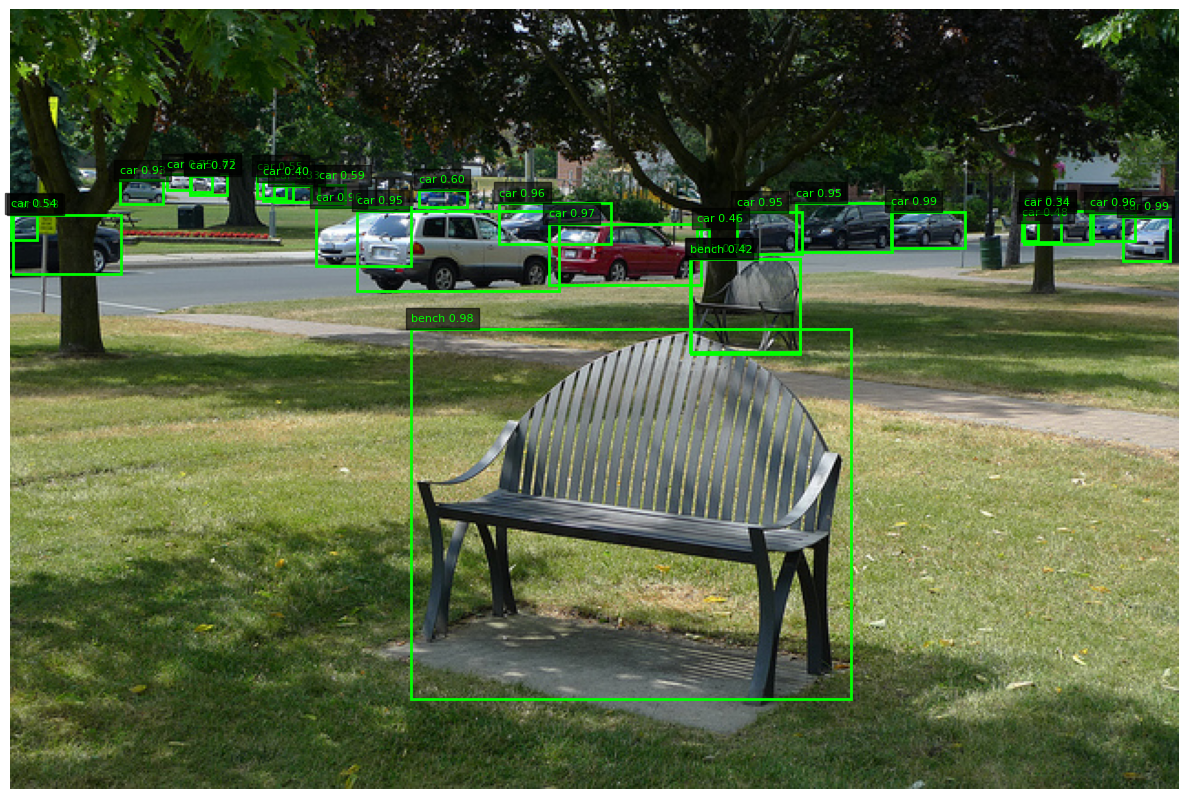

In [4]:
# Visualize detections on the image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image

# COCO class names (same order as model output)
COCO_CLASSES = (
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train',
    'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep',
    'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard',
    'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard',
    'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork',
    'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange',
    'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair',
    'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv',
    'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave',
    'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase',
    'scissors', 'teddy bear', 'hair drier', 'toothbrush')

sample = result[0]
pred = sample.pred_instances
meta = sample.metainfo
img_path = meta.get('img_path', 'onedl-mmdetection/demo/demo.jpg')

# Load image (original size)
img = np.array(Image.open(img_path).convert('RGB'))
h, w = img.shape[:2]

# Bboxes are already in original image coordinates (mmdeploy rescales them in the backend)
bboxes = pred.bboxes.cpu().numpy()
scores = pred.scores.cpu().numpy()
labels = pred.labels.cpu().numpy().astype(int)

# Keep only confident detections for clearer visualization
score_thr = 0.3
keep = scores >= score_thr
bboxes = bboxes[keep]
scores = scores[keep]
labels = labels[keep]

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.imshow(img)

for bbox, score, label in zip(bboxes, scores, labels):
    x1, y1, x2, y2 = bbox
    rect = mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2,
                               edgecolor='lime', facecolor='none')
    ax.add_patch(rect)
    cls_name = COCO_CLASSES[label] if label < len(COCO_CLASSES) else f'cls{label}'
    ax.text(x1, y1 - 4, f'{cls_name} {score:.2f}', color='lime', fontsize=8,
            bbox=dict(facecolor='black', alpha=0.6))

ax.axis('off')
plt.tight_layout()
plt.show()